In [1]:
# Install (only once)
!pip install torch torchvision

# Common imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = 20
latent_dim = 2

inputs = Input(shape=(input_dim,))
x = Dense(10, activation='relu')(inputs)
latent = Dense(latent_dim)(x)
x = Dense(10, activation='relu')(latent)
outputs = Dense(input_dim, activation='sigmoid')(x)

vae = Model(inputs, outputs)
vae.compile(optimizer='adam', loss='mse')

In [3]:
data = np.random.normal(size=(1000, input_dim))
history = vae.fit(data, data, epochs=10)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2443 
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2129 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1744
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1314 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0879 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0506
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0241 
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0084 
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9992 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9936 


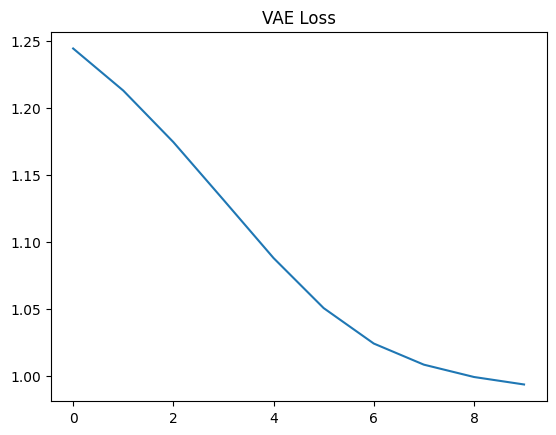

In [4]:
plt.plot(history.history['loss'])
plt.title("VAE Loss")
plt.show()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

generator = Sequential([
    Dense(16, activation='relu', input_dim=10),
    Dense(1)
])

discriminator = Sequential([
    Dense(16, activation='relu', input_dim=1),
    Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
for epoch in range(200):
    noise = np.random.randn(32,10)
    fake = generator.predict(noise, verbose=0)

    real = np.random.randn(32,1)

    X = np.vstack([real, fake])
    y = np.vstack([np.ones((32,1)), np.zeros((32,1))])

    loss = discriminator.train_on_batch(X, y)

print("GAN Done")

GAN Done


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


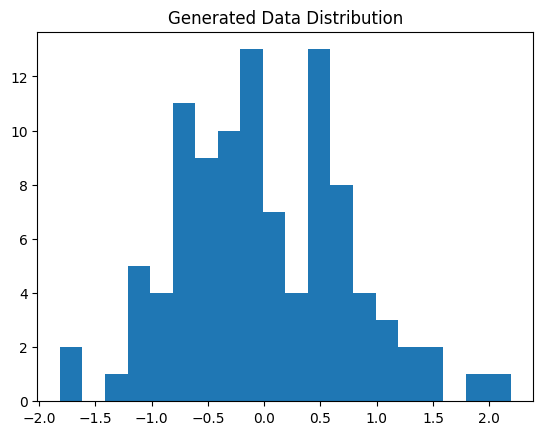

In [7]:
noise = np.random.randn(100,10)
generated = generator.predict(noise)

plt.hist(generated, bins=20)
plt.title("Generated Data Distribution")
plt.show()

In [8]:
import torch
import torch.nn as nn

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(10, 2)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)
        return self.fc(x)

In [9]:
adj = torch.tensor([
    [1,1,0,0,0],
    [1,1,1,0,0],
    [0,1,1,1,0],
    [0,0,1,1,1],
    [0,0,0,1,1]
], dtype=torch.float32)

features = torch.rand(5,10)

model = GCN()
output = model(features, adj)

print(output)

tensor([[-0.0928, -0.2720],
        [-0.1107, -0.2964],
        [ 0.0398, -0.2244],
        [ 0.0947, -0.3613],
        [ 0.1125, -0.3369]], grad_fn=<AddmmBackward0>)
